## Sleep Disorder Classification from Physiological & Lifestyle Indicators

The dataset contains anonymised clinical records covering sleep health, lifestyle patterns, and physiological measurements. It is used to classify three sleep disorder outcomes: None, Insomnia, and Sleep Apnea. Each record includes wearable-compatible metrics (heart rate, daily steps) alongside clinical assessments (BMI, blood pressure) and self-reported lifestyle data (occupation, stress level, physical activity).

#### Author: Jessica Addy

### 1. Import Data and Necessary Package

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              roc_auc_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# ── Style constants (matching do-you-sleep-well palette) ──
SLEEP_COLORS = ["#4F46E5", "#0EA5E9", "#8B5CF6", "#22D3EE", "#F59E0B", "#10B981", "#EF4444"]
CLASS_COLORS = {"Insomnia": "#EF4444", "None": "#10B981", "Sleep Apnea": "#4F46E5"}

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

print("All imports successful")

All imports successful


### 2. Data Loading & Cleaning

In [38]:
df = pd.read_csv("D:/MINE/Personal Projects/Sleep Prediction/Sleep_health_and_lifestyle_dataset.csv")
print(df.shape)
print(df.dtypes)

(374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [39]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


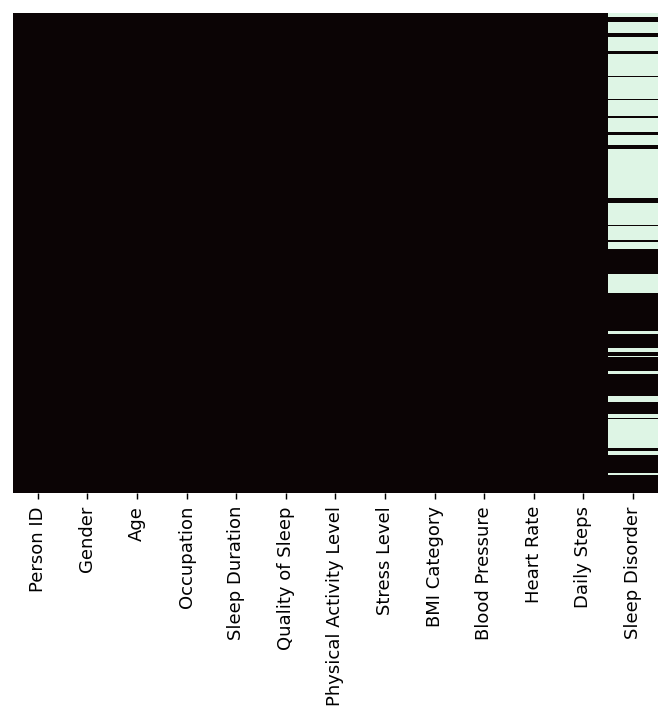

In [41]:
sns.heatmap(df.isnull(), yticklabels= False, cbar= False, cmap= "mako")
plt.show()

In [42]:
# Fix NaN   
df['Sleep Disorder'].fillna('None', inplace=True)

# Parse Blood Pressure string 
df[['Systolic_BP', 'Diastolic_BP']] = (df['Blood Pressure'].str.split('/', expand=True).astype(int))
df.drop('Blood Pressure', axis=1, inplace=True)

#Drop ID 
df.drop('Person ID', axis=1, inplace=True)

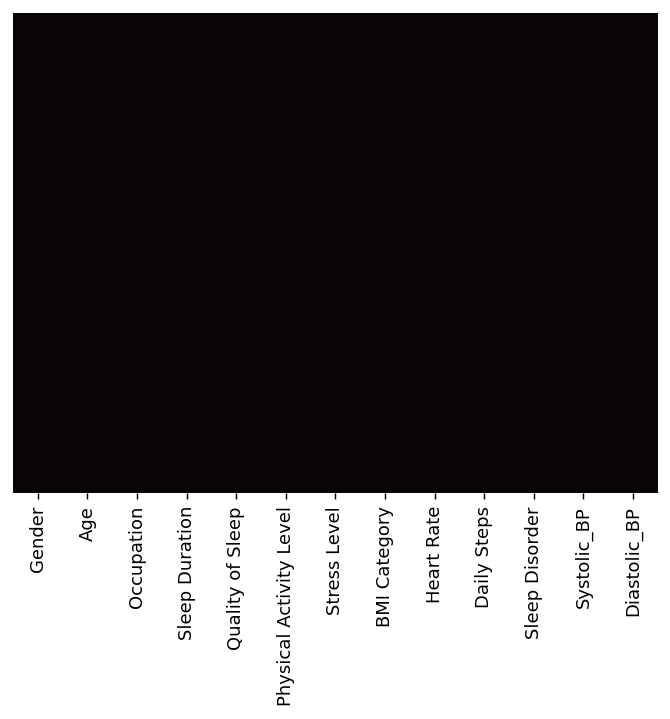

In [43]:
sns.heatmap(df.isnull(), yticklabels= False, cbar= False, cmap= "mako")
plt.show()

### 3. Clinical Feature Engineering 

Four clinically-motivated features were derived on this dataset:

- **Pulse Pressure (systolic − diastolic):** marker of arterial stiffness, elevated in sleep apnea
- **Activity-Stress Ratio:** proxy for physiological recovery capacity
- **Sleep Quality per Hour:** efficiency metric beyond raw duration
- **Age–Stress Interaction:** multiplicative risk amplifier from the do-you-sleep-well EDA

In [44]:
#Pulse pressure (systolic - diastolic) — clinical feature
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']

# Steps-per-stress ratio 
df['Activity_Stress_Ratio'] = df['Daily Steps'] / (df['Stress Level'] + 1)

# Sleep efficiency proxy
df['Sleep_Quality_per_Hour'] = df['Quality of Sleep']/ df['Sleep Duration']

#Age Stress Interaction
df['Age_Stress_Interaction'] = df['Age'] * df['Stress Level']   

In [45]:
df.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP',
       'Pulse_Pressure', 'Activity_Stress_Ratio', 'Sleep_Quality_per_Hour',
       'Age_Stress_Interaction'],
      dtype='object')

### 4. Exploratory Data Analysis

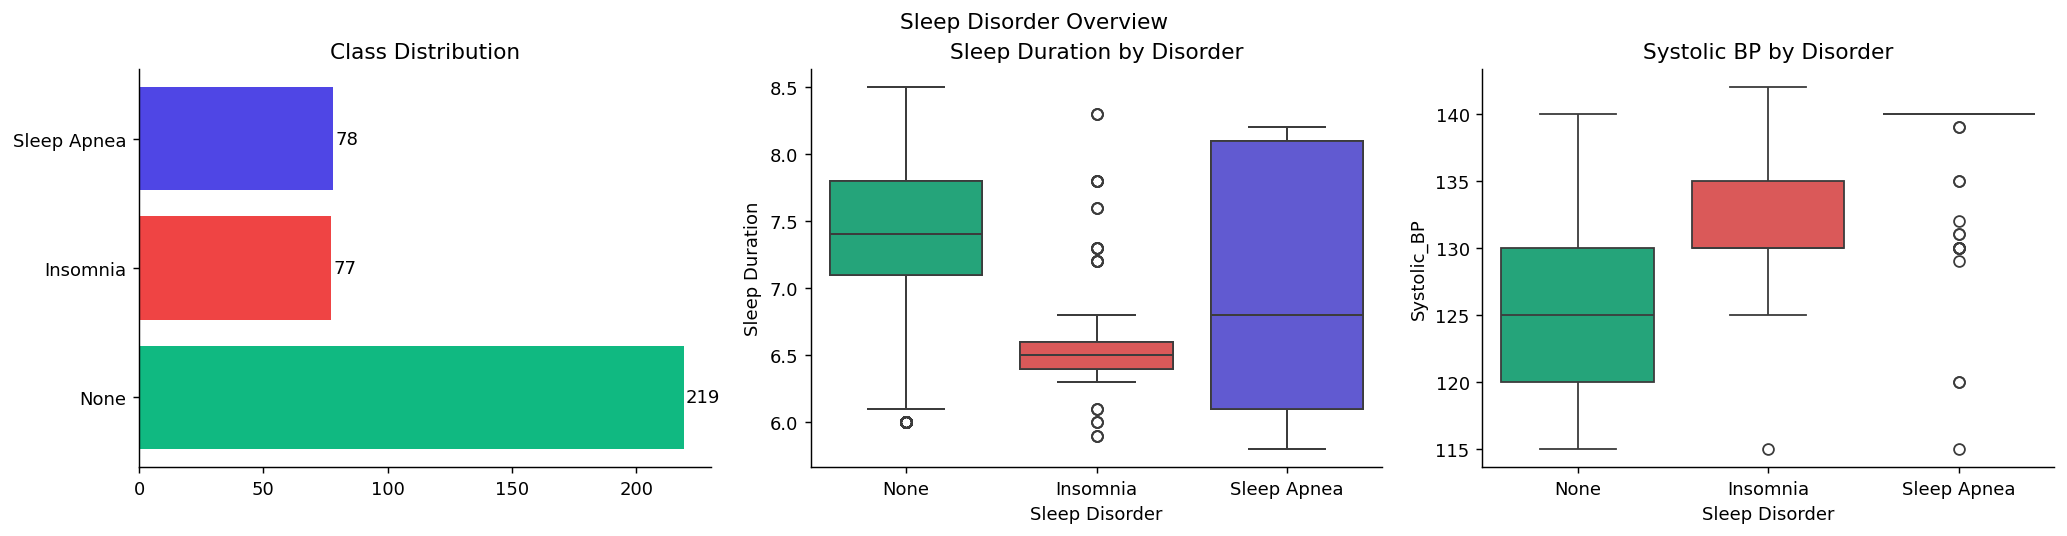

In [46]:
# Class distribution & key sleep metrics by disorder ─
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

order = ['None', 'Insomnia', 'Sleep Apnea']
colors = [CLASS_COLORS[c] for c in order]

counts = df['Sleep Disorder'].value_counts().reindex(order)
axes[0].barh(order, counts.values, color=colors)
axes[0].set_title('Class Distribution')
for i, v in enumerate(counts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)


    
    sns.boxplot(x='Sleep Disorder', y='Sleep Duration', data=df,
            order=order, palette=CLASS_COLORS, ax=axes[1])
axes[1].set_title('Sleep Duration by Disorder')



sns.boxplot(x='Sleep Disorder', y='Systolic_BP', data=df,
            order=order, palette=CLASS_COLORS, ax=axes[2])
axes[2].set_title('Systolic BP by Disorder')

plt.tight_layout()
plt.suptitle('Sleep Disorder Overview', y=1.02)
plt.show()

In [47]:
df.groupby('Occupation')['Occupation'].count()

Occupation
Accountant              37
Doctor                  71
Engineer                63
Lawyer                  47
Manager                  1
Nurse                   73
Sales Representative     2
Salesperson             32
Scientist                4
Software Engineer        4
Teacher                 40
Name: Occupation, dtype: int64

In [48]:
df.groupby('Gender')['Gender'].count()

Gender
Female    185
Male      189
Name: Gender, dtype: int64

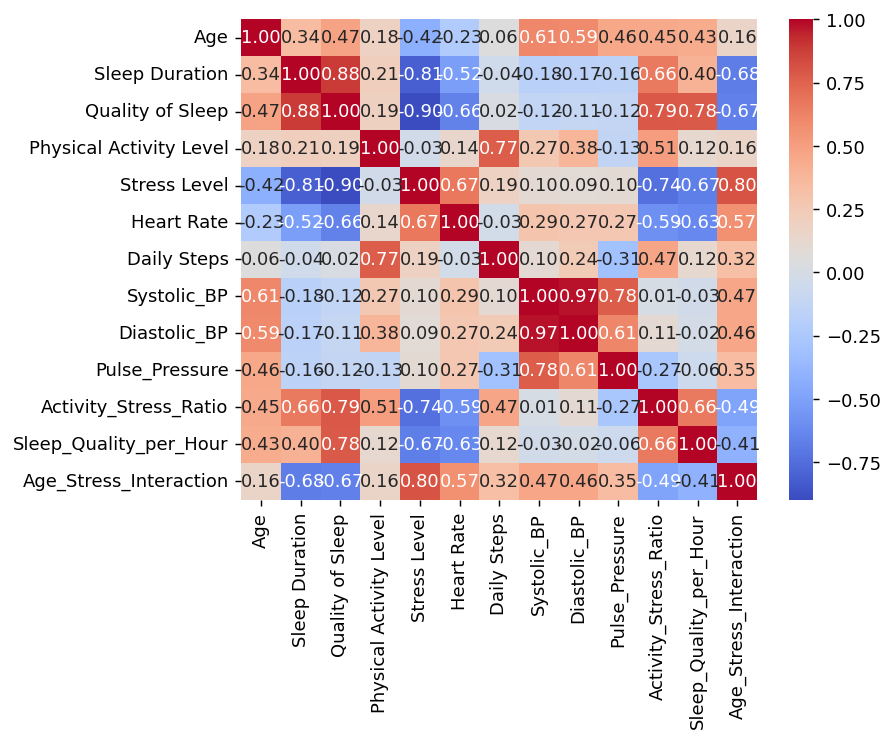

In [49]:
# Correlation heatmap (numeric only)
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [50]:
ct = pd.crosstab(df['Occupation'], df['Sleep Disorder'])
ct

Sleep Disorder,Insomnia,None,Sleep Apnea
Occupation,,,
Accountant,7,30,0
Doctor,3,64,4
Engineer,5,57,1
Lawyer,2,42,3
Manager,0,1,0
Nurse,3,9,61
Sales Representative,0,0,2
Salesperson,29,2,1
Scientist,0,2,2


In [51]:
ct_pct = pd.crosstab(df['Occupation'], df['Sleep Disorder'], normalize='index') * 100
ct_pct.round(1)

Sleep Disorder,Insomnia,None,Sleep Apnea
Occupation,,,
Accountant,18.9,81.1,0.0
Doctor,4.2,90.1,5.6
Engineer,7.9,90.5,1.6
Lawyer,4.3,89.4,6.4
Manager,0.0,100.0,0.0
Nurse,4.1,12.3,83.6
Sales Representative,0.0,0.0,100.0
Salesperson,90.6,6.2,3.1
Scientist,0.0,50.0,50.0


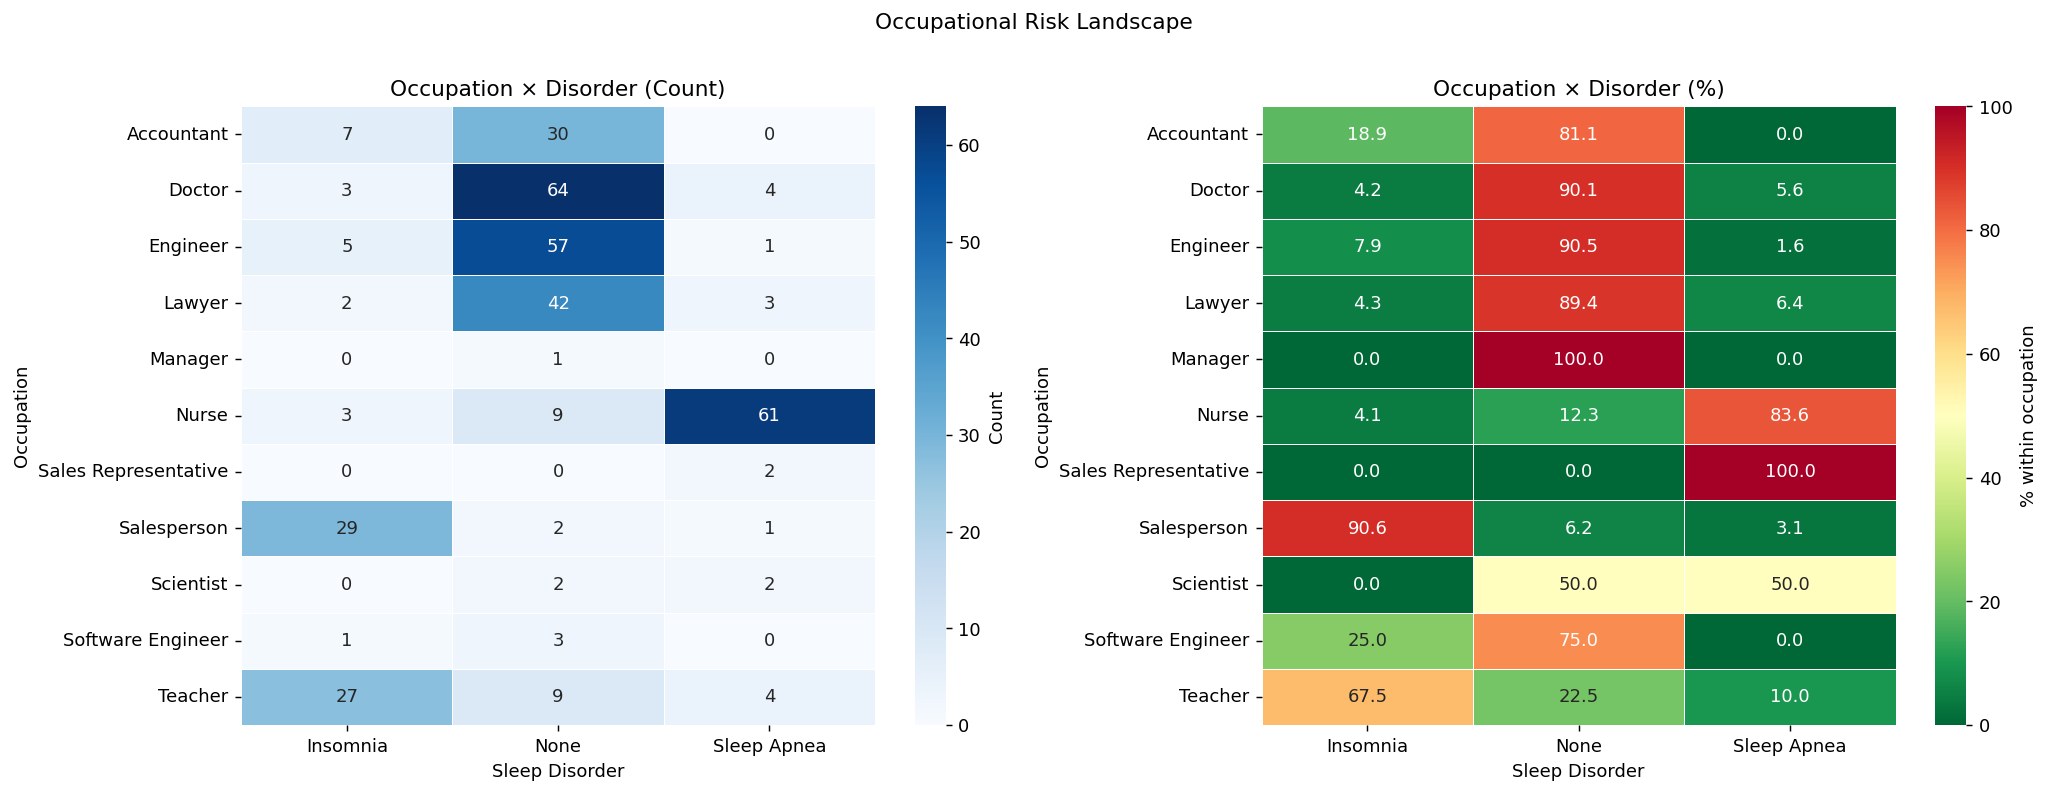

In [52]:
# Occupation × Disorder heatmap 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=.5, cbar_kws={'label': 'Count'})
axes[0].set_title('Occupation × Disorder (Count)')

sns.heatmap(ct_pct.round(1), annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=.5, cbar_kws={'label': '% within occupation'})
axes[1].set_title('Occupation × Disorder (%)')

plt.suptitle('Occupational Risk Landscape', y=1.01)
plt.tight_layout()
plt.show()

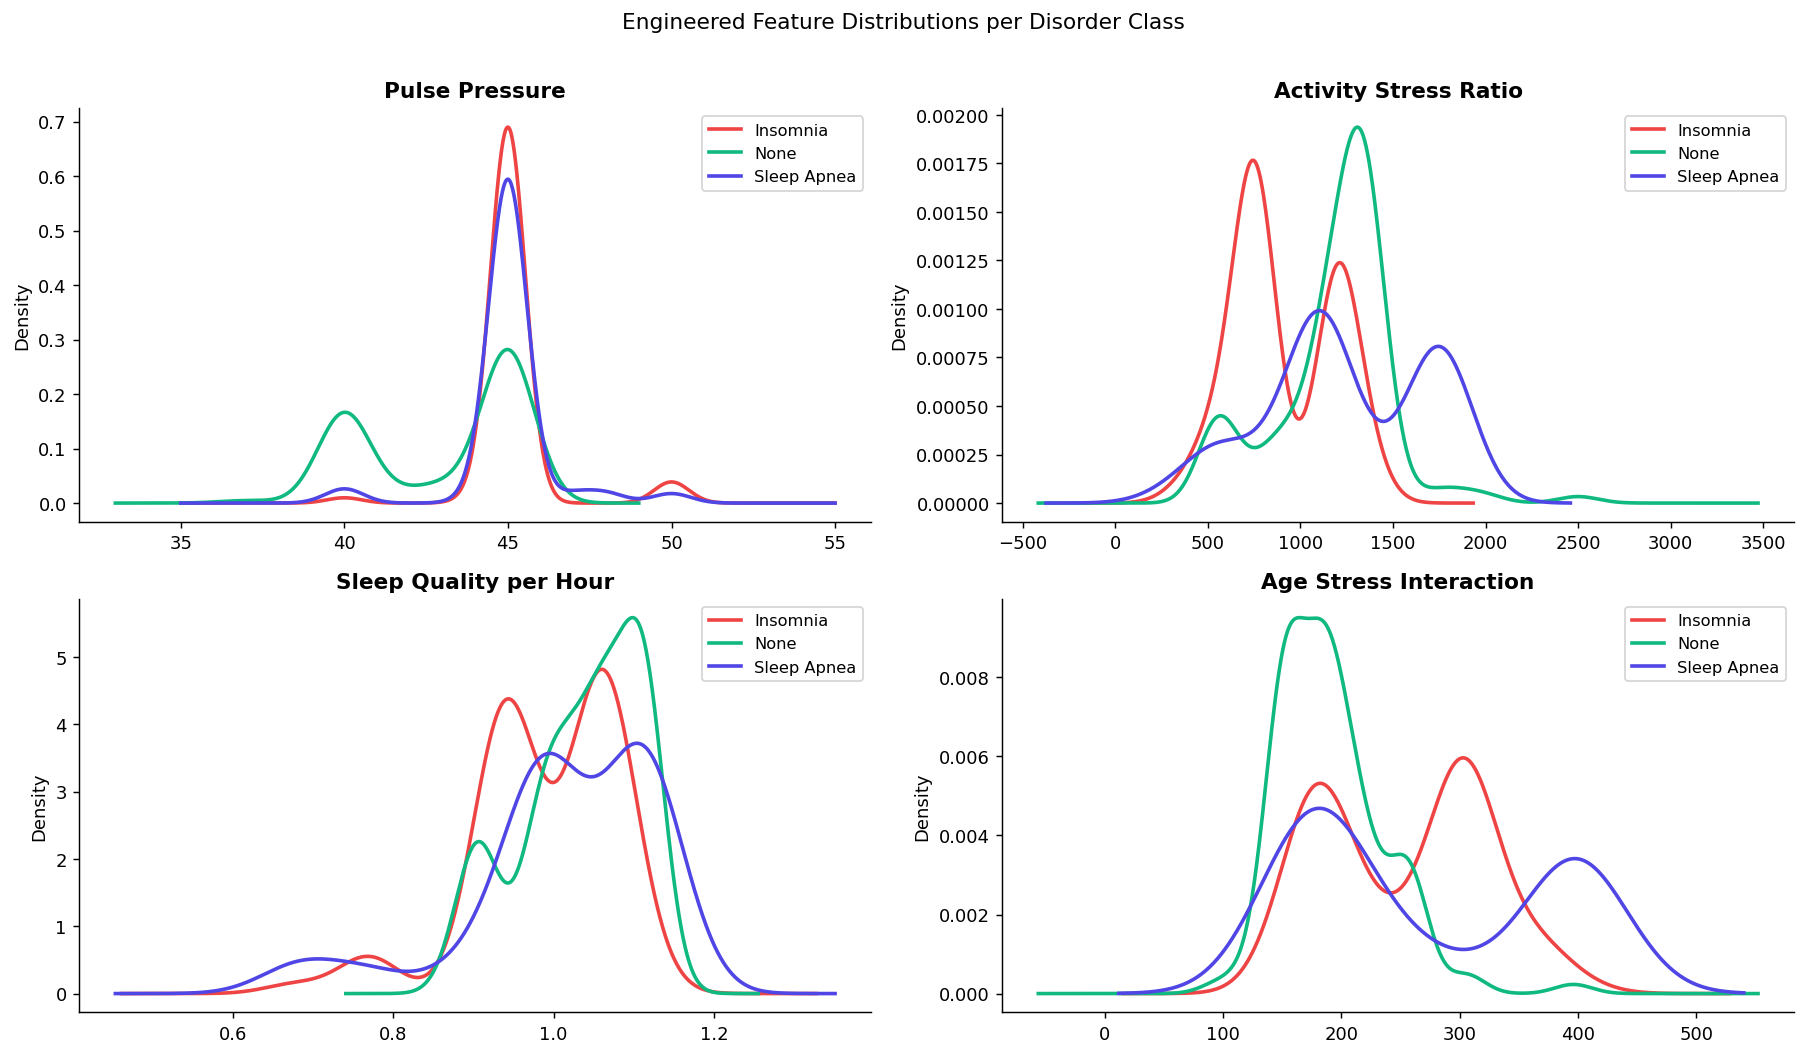

In [53]:
# Engineered feature distributions by class
eng_plot = ['Pulse_Pressure', 'Activity_Stress_Ratio',
            'Sleep_Quality_per_Hour', 'Age_Stress_Interaction']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flat, eng_plot):
    for cls, col in CLASS_COLORS.items():
        subset = df[df['Sleep Disorder'] == cls][feat].dropna()
        subset.plot(kind='kde', ax=ax, color=col, label=cls, linewidth=2)
    ax.set_title(feat.replace('_', ' '), fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Engineered Feature Distributions per Disorder Class', y=1.01)
plt.tight_layout()
plt.show()

### 5.Preprocessing Pipeline

In [54]:
#Define TARGET variable
target = 'Sleep Disorder'

#Encode categorical labels → numeric
model = LabelEncoder()
y = model.fit_transform(df[target])  # 0=Insomnia, 1=None, 2=Sleep Apnea


#Create feature matrix
X = df.drop(target, axis=1)

#Inspect class labels
print(f"\nClasses: {model.classes_}")

#Check class distribution
print(f"Distribution: {np.bincount(y)/len(y)}")

#Train-test split (with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

#Print shapes
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Classes: ['Insomnia' 'None' 'Sleep Apnea']
Distribution: [0.20588235 0.5855615  0.20855615]

Train: (261, 16) | Test: (113, 16)


In [55]:
num_features = X.select_dtypes(include='number').columns.tolist()
print(f"Numeric Features: {num_features}")

Numeric Features: ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure', 'Activity_Stress_Ratio', 'Sleep_Quality_per_Hour', 'Age_Stress_Interaction']


In [56]:
cat_features  = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical Features: {cat_features}")

Categorical Features: ['Gender', 'Occupation', 'BMI Category']


In [57]:
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                       ('sc',  StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, num_features),
                                  ('cat', cat_pipe, cat_features)
])

### 6.Model Selection

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'Logistic Reg' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'k-NN'          : KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Decision Tree' : DecisionTreeClassifier(max_depth=6, class_weight='balanced'),
    'Random Forest' : RandomForestClassifier(n_estimators=300, oob_score=True, class_weight='balanced', n_jobs=-1),
    'SVM (RBF)'     : SVC(C=10, kernel='rbf', class_weight='balanced', probability=True),
    'GBM'           : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05),
    'XGBoost'       : xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, colsample_bytree=0.8,eval_metric='mlogloss', random_state=42),
}
results = {}

print("\n── Algorithm Benchmark ──")

for name, clf in all_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    s = cross_val_score(pipe, X_train, y_train, cv=cv,
                         scoring='roc_auc_ovr', n_jobs=-1)
    results[name] = s.mean()
    print(f"{name:16s}  AUC: {s.mean():.4f} ± {s.std():.4f}")


── Algorithm Benchmark ──
Logistic Reg      AUC: 0.9223 ± 0.0365
k-NN              AUC: 0.9276 ± 0.0343
Decision Tree     AUC: 0.8900 ± 0.0349
Random Forest     AUC: 0.9234 ± 0.0469
SVM (RBF)         AUC: 0.9249 ± 0.0388
GBM               AUC: 0.9253 ± 0.0362
XGBoost           AUC: 0.9258 ± 0.0426


### 7. SMOTE (Synthetic Minority Oversampling Technique).

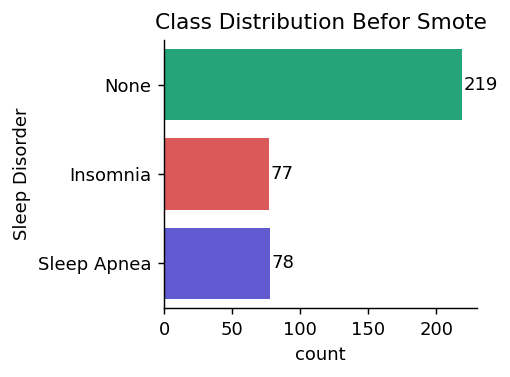

In [59]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(data=df,
              y='Sleep Disorder',
              order=order,
              palette=colors,
              ax=ax)

ax.set_title('Class Distribution Befor Smote')

# Adding counts
for p in ax.patches:
    ax.text(p.get_width() + 1,
            p.get_y() + p.get_height()/2,
            int(p.get_width()),
            va='center')

plt.tight_layout()

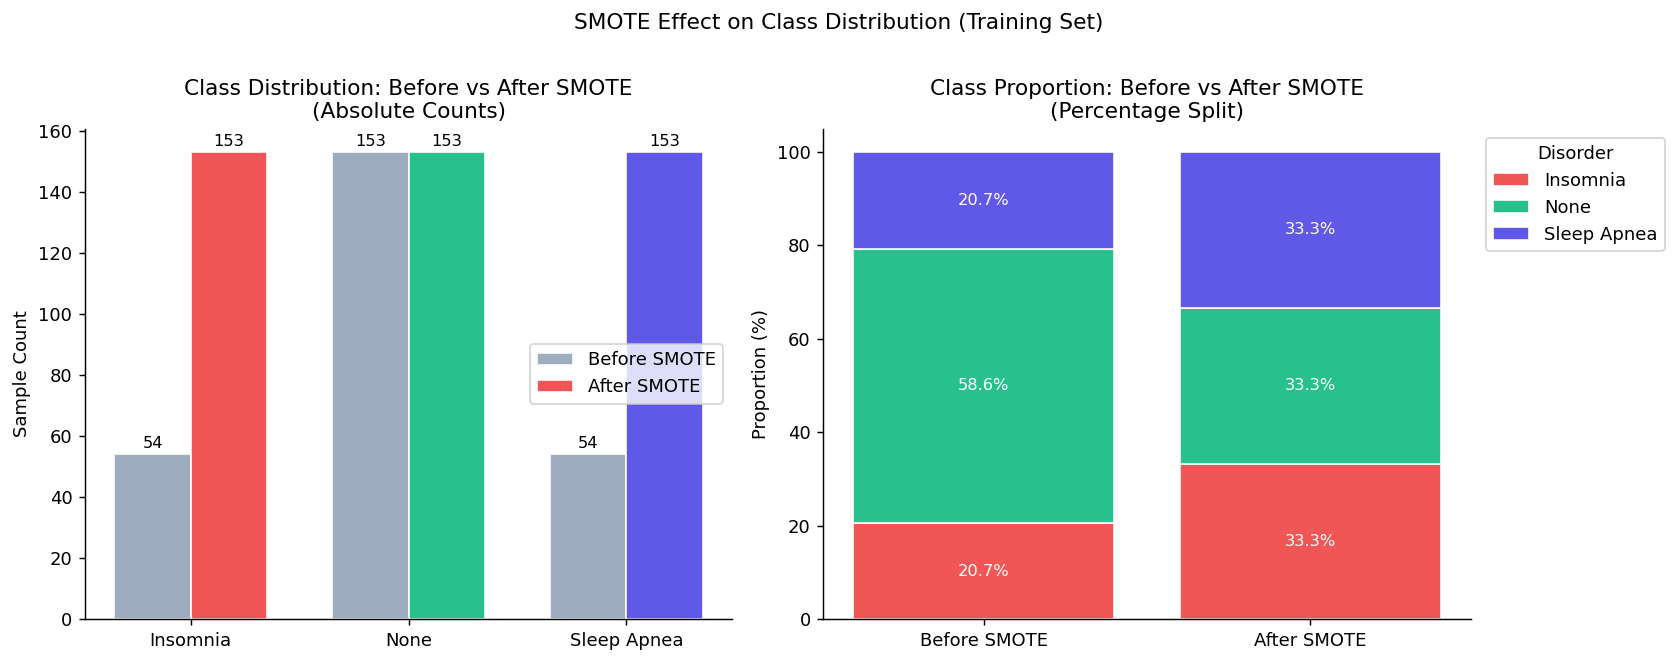


 Before/After SMOTE Summary
Insomnia      Before:  54  After: 153  (+99 synthetic samples, 20.7% → 33.3%)
None          Before: 153  After: 153  (+0 synthetic samples, 58.6% → 33.3%)
Sleep Apnea   Before:  54  After: 153  (+99 synthetic samples, 20.7% → 33.3%)


In [60]:
# Before SMOTE and After SMOTE [side-by-side] 
from collections import Counter
from imblearn.over_sampling import SMOTE

# Transform training data to get numeric array for SMOTE
prep_fit = preprocessor.fit(X_train, y_train)  # fit preprocessor
X_train_t = prep_fit.transform(X_train)

smote = SMOTE(k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X_train_t, y_train)

before_counts = Counter(y_train)
after_counts  = Counter(y_res)

class_labels = model.classes_
before_vals  = [before_counts[i] for i in range(len(class_labels))]
after_vals   = [after_counts[i]  for i in range(len(class_labels))]

x = np.arange(len(class_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

#  Left: grouped bar (absolute counts) 
bars_b = axes[0].bar(x - width/2, before_vals, width, label='Before SMOTE',
                      color=['#94A3B8']*3, edgecolor='white', alpha=0.9)
bars_a = axes[0].bar(x + width/2, after_vals,  width, label='After SMOTE',
                      color=[CLASS_COLORS[c] for c in class_labels],
                      edgecolor='white', alpha=0.9)

for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(class_labels)
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Class Distribution: Before vs After SMOTE\n(Absolute Counts)')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: percentage pie-style stacked bar ──
before_pct = np.array(before_vals) / sum(before_vals) * 100
after_pct  = np.array(after_vals)  / sum(after_vals)  * 100

bars_list = [before_pct, after_pct]
bar_labels = ['Before SMOTE', 'After SMOTE']
bottoms = [np.zeros(2), np.zeros(2)]

x2 = np.arange(2)
for i, cls in enumerate(class_labels):
    vals = [before_pct[i], after_pct[i]]
    bottom = [before_pct[:i].sum(), after_pct[:i].sum()]
    axes[1].bar(x2, vals, bottom=bottom,
                 color=CLASS_COLORS[cls], label=cls,
                 edgecolor='white', alpha=0.9)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            axes[1].text(j, b + v/2, f'{v:.1f}%', ha='center', va='center',
                          fontsize=9, color='white')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(bar_labels)
axes[1].set_ylabel('Proportion (%)')
axes[1].set_title('Class Proportion: Before vs After SMOTE\n(Percentage Split)')
axes[1].legend(title='Disorder', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('SMOTE Effect on Class Distribution (Training Set)',y=1.01)
plt.tight_layout()
plt.show()

print("\n Before/After SMOTE Summary")
for i, cls in enumerate(class_labels):
    gain = after_counts[i] - before_counts[i]
    print(f"{cls:12s}  Before: {before_counts[i]:3d}  After: {after_counts[i]:3d}  "
          f"(+{gain} synthetic samples, {before_pct[i]:.1f}% → {after_pct[i]:.1f}%)")

## 9. Final Model — SMOTE + XGBoost (for SHAP)

In [61]:
final_model = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 10. Model Evaluation


 Test Set Results
              precision    recall  f1-score   support

    Insomnia       0.83      0.87      0.85        23
        None       0.95      0.95      0.95        66
 Sleep Apnea       0.83      0.79      0.81        24

    accuracy                           0.90       113
   macro avg       0.87      0.87      0.87       113
weighted avg       0.90      0.90      0.90       113

ROC-AUC (macro): 0.938
F1 macro:        0.871


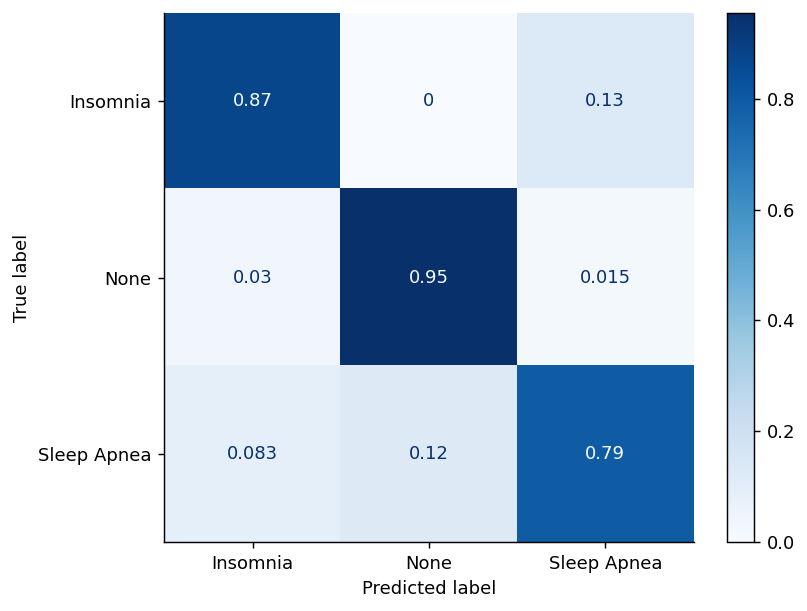

In [62]:
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print("\n Test Set Results")
print(classification_report(y_test, y_pred, target_names=model.classes_))
print(f"ROC-AUC (macro): {roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'):.3f}")
print(f"F1 macro:        {f1_score(y_test, y_pred, average='macro'):.3f}")


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=model.classes_, cmap='Blues', normalize='true')
plt.tight_layout(); plt.show()


In [63]:
xgb_clf = final_model.named_steps['clf']
xgb_clf

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [64]:
# Apply preprocessor but NOT smote (smote is train-only)
X_test_transformed = final_model.named_steps['prep'].transform(X_test)

### 11. SHAP Explainability

In [65]:
# ── Build feature name list after OHE ──
ohe_names = list(
    final_model.named_steps['prep']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(cat_features)
)
all_feature_names = num_features + ohe_names

X_test_t = final_model.named_steps['prep'].transform(X_test)

explainer  = shap.TreeExplainer(final_model.named_steps['clf'])
shap_vals  = explainer.shap_values(X_test_t)  # list of 3 arrays [n_test × n_feat]

print(f"SHAP computed for {len(model.classes_)} classes × {X_test_t.shape[0]} test samples")
print(f"Feature count: {X_test_t.shape[1]}")

SHAP computed for 3 classes × 113 test samples
Feature count: 27


In [66]:
gbm_clf        = final_model.named_steps['clf']
X_test_t       = final_model.named_steps['prep'].transform(X_test)
explainer      = shap.TreeExplainer(gbm_clf)
shap_vals      = explainer.shap_values(X_test_t)
shap_vals_list = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]

print(f"shap_vals shape:    {shap_vals.shape}")       # (113, 27, 3)
print(f"shap_vals_list len: {len(shap_vals_list)}")   # 3
print(f"per-class shape:    {shap_vals_list[0].shape}") # (113, 27)

shap_vals shape:    (113, 27, 3)
shap_vals_list len: 3
per-class shape:    (113, 27)



  SHAP Beeswarm — Class: Insomnia


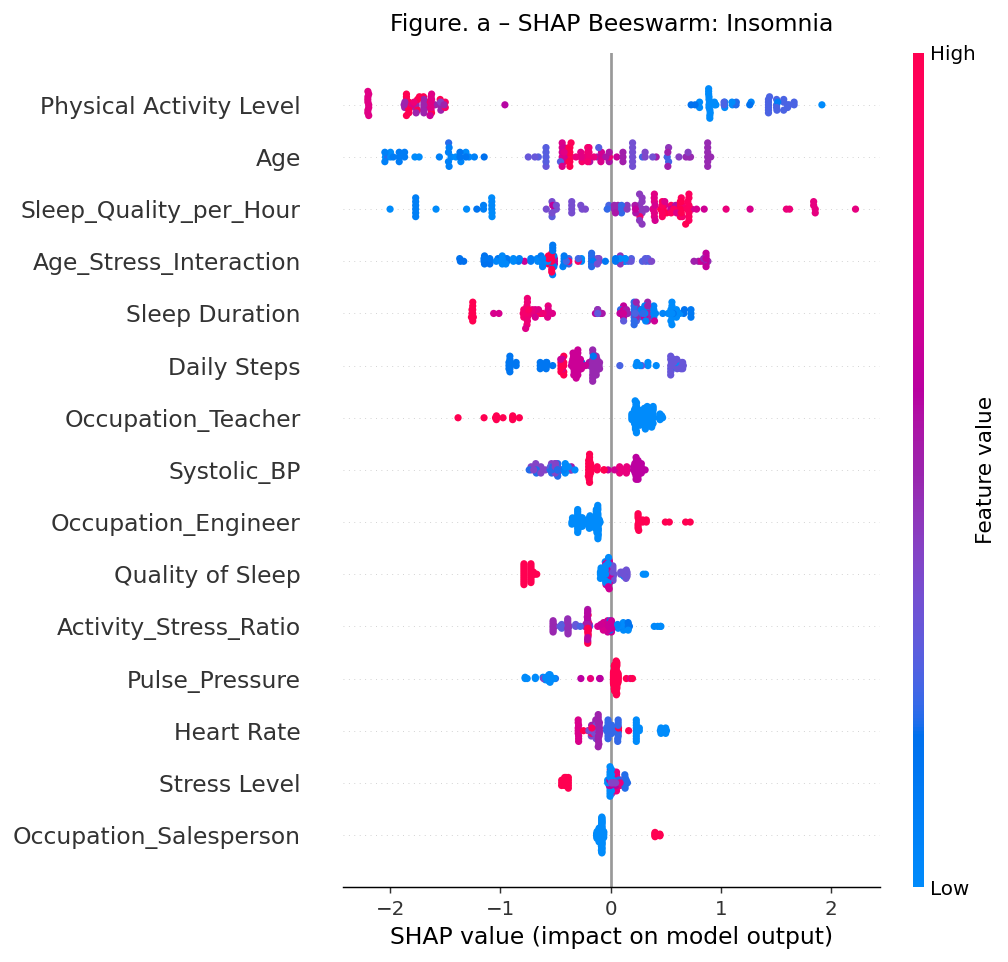


  SHAP Beeswarm — Class: None


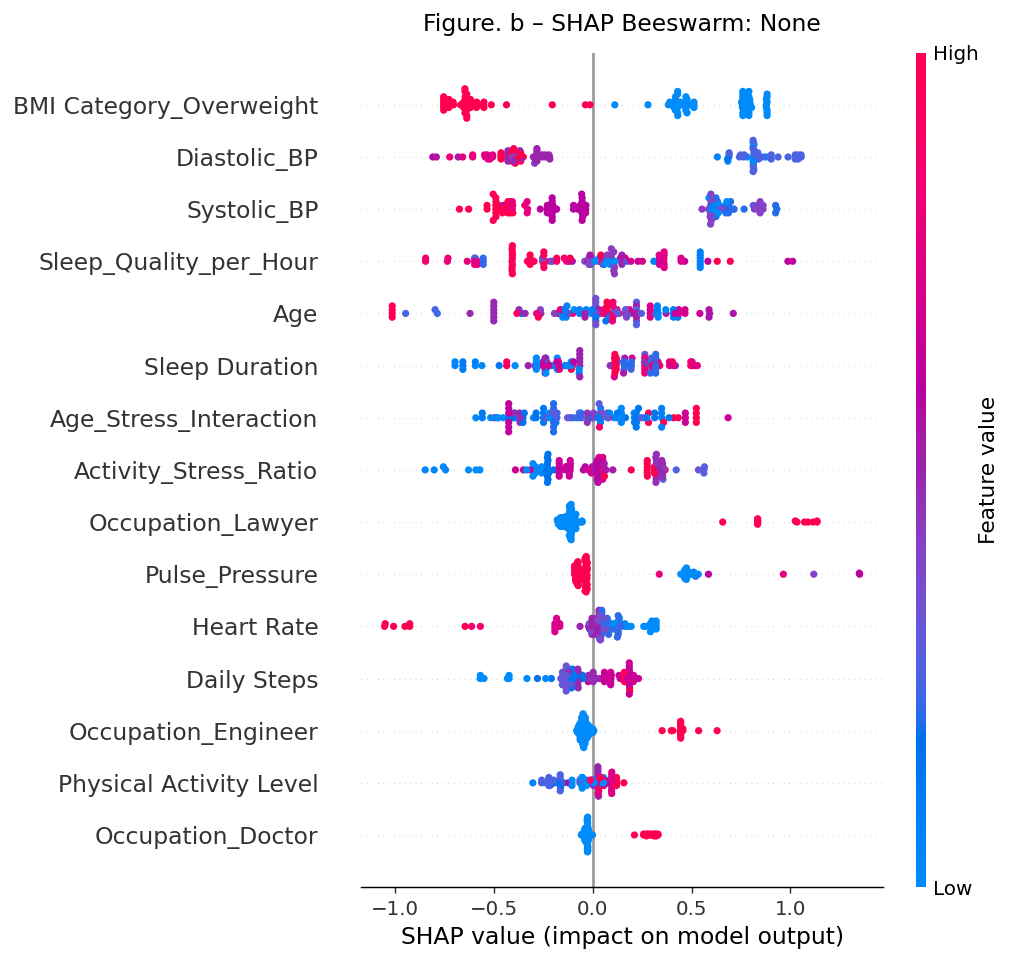


  SHAP Beeswarm — Class: Sleep Apnea


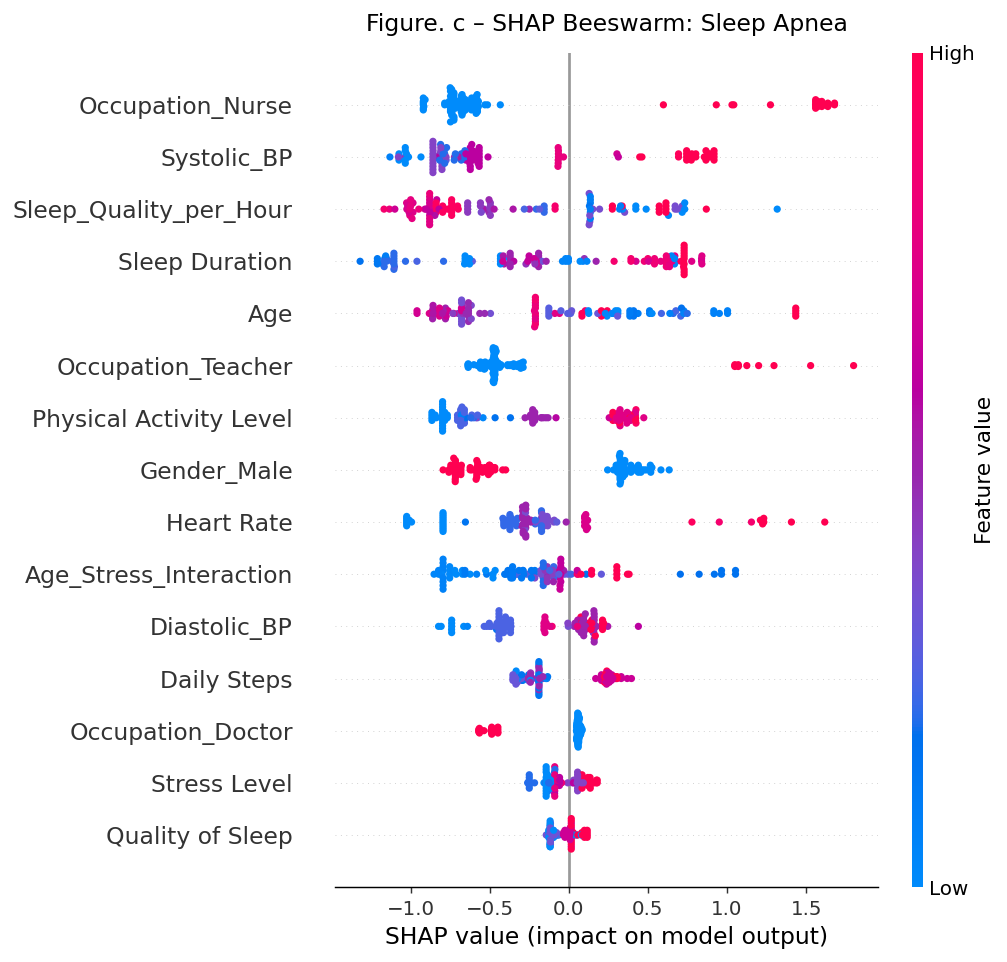

In [67]:
for i, cls in enumerate(model.classes_):
    print(f"\n{'='*60}")
    print(f"  SHAP Beeswarm — Class: {cls}")
    print(f"{'='*60}")

    shap.summary_plot(
        shap_vals_list[i],
        X_test_t,
        feature_names=all_feature_names,
        max_display=15,
        show=False
    )

    plt.title(f'Figure. {chr(97+i)} – SHAP Beeswarm: {cls}', fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

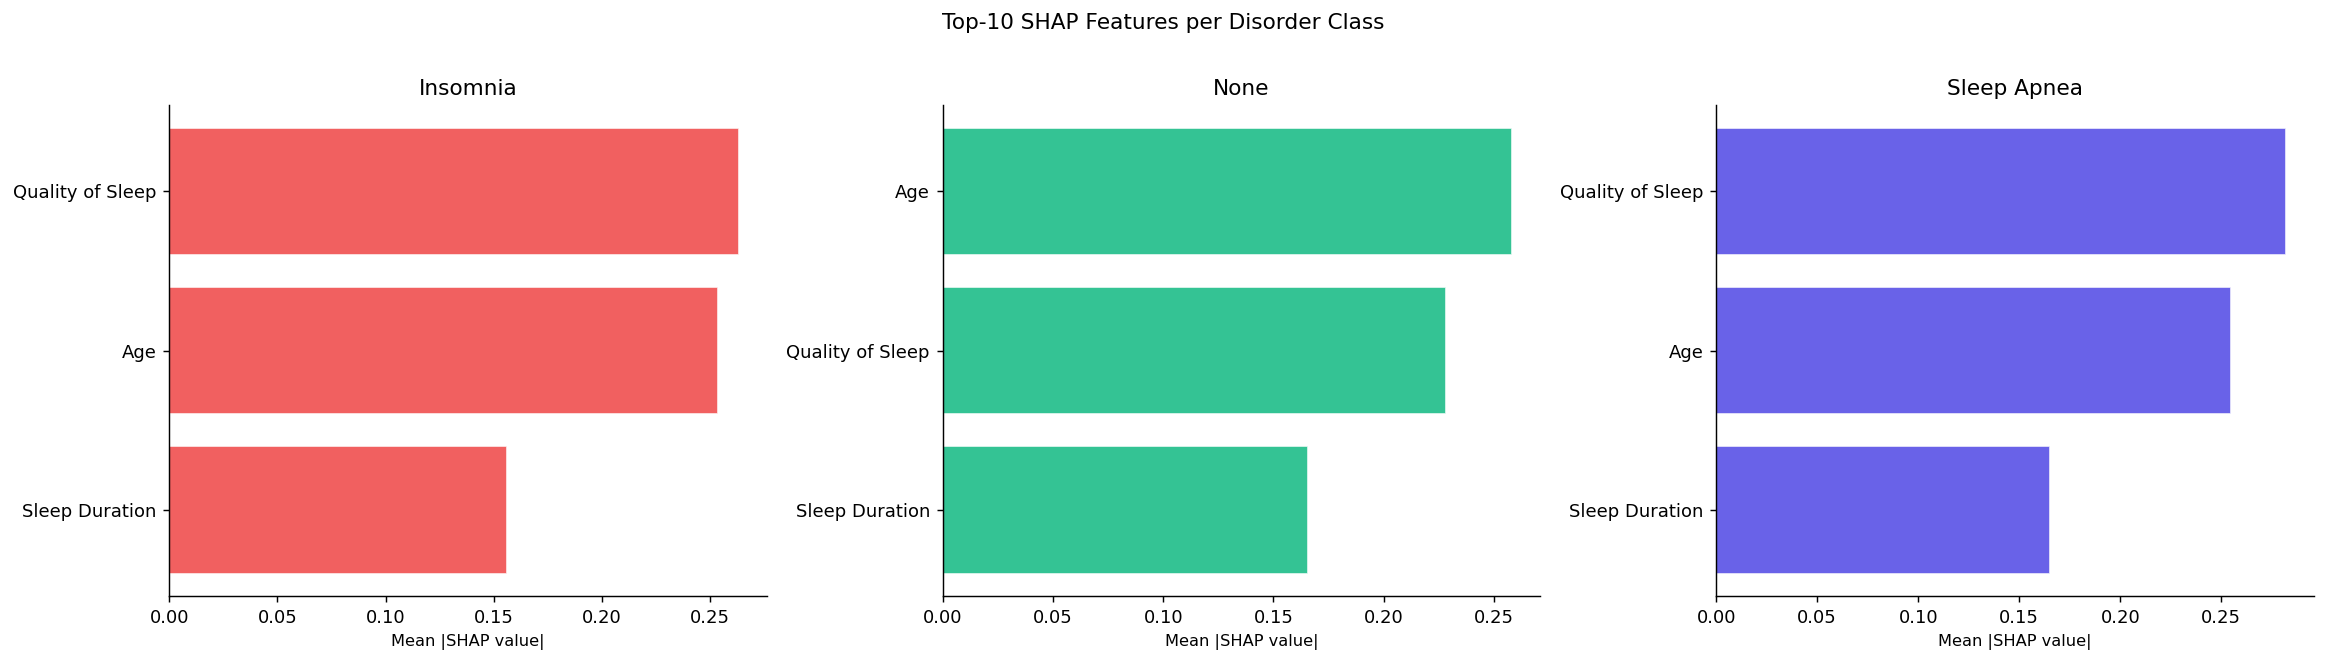

In [68]:
# Top-5 SHAP features per class (bar summary for publication) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, (cls, ax) in enumerate(zip(model.classes_, axes)):
    mean_abs = np.abs(shap_vals[i]).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:10]
    top_names = [all_feature_names[j] for j in top_idx]
    top_vals  = mean_abs[top_idx]

    ax.barh(top_names[::-1], top_vals[::-1],
            color=list(CLASS_COLORS.values())[i], alpha=0.85, edgecolor='white')
    ax.set_title(f'{cls}',fontsize=12)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)

plt.suptitle('Top-10 SHAP Features per Disorder Class', y=1.01)
plt.tight_layout()
plt.show()

### 12. Risk Prevalence By Occupation

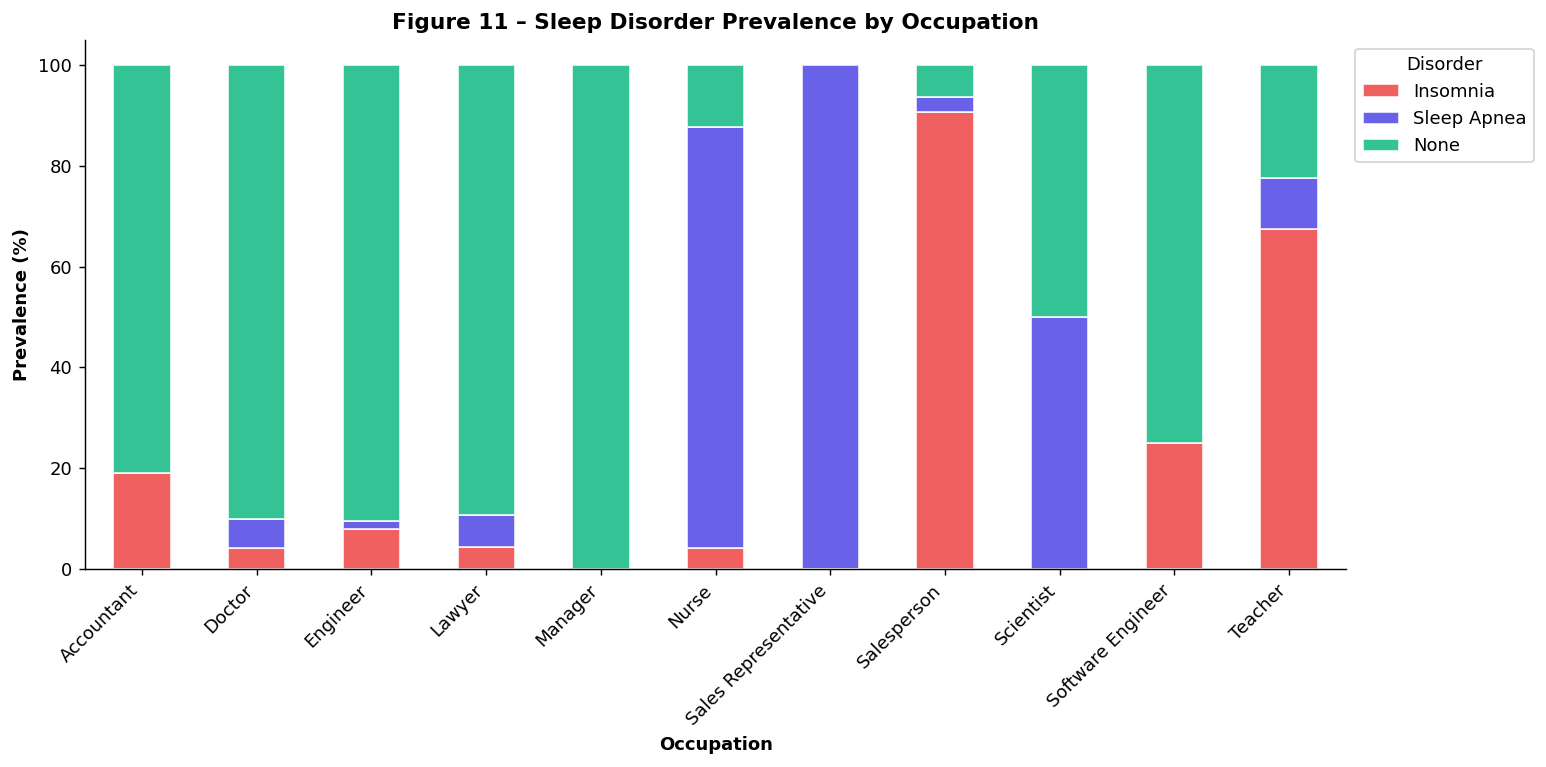

In [69]:
occ_risk = (
    df.groupby('Occupation')['Sleep Disorder']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Prevalence (%)')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = occ_risk.pivot(index='Occupation', columns='Sleep Disorder', values='Prevalence (%)')
pivot[['Insomnia', 'Sleep Apnea', 'None']].plot(kind='bar', stacked=True, ax=ax,
    color=[CLASS_COLORS['Insomnia'], CLASS_COLORS['Sleep Apnea'], CLASS_COLORS['None']],
    edgecolor='white', alpha=0.85)
ax.set_xlabel('Occupation', fontweight='bold')
ax.set_ylabel('Prevalence (%)', fontweight='bold')
ax.set_title('Figure 11 – Sleep Disorder Prevalence by Occupation', fontweight='bold')
ax.legend(title='Disorder', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
# Decision tree rules per occupation cluster 
# Group occupations into clinical risk tiers based on disorder prevalence
disorder_rate = df.groupby('Occupation').apply(
    lambda g: (g['Sleep Disorder'] != 'None').mean()
).sort_values(ascending=False)

print("Disorder prevalence by occupation:")
print(disorder_rate.round(3).to_string())

high_risk_occs  = disorder_rate[disorder_rate >= 0.5].index.tolist()
low_risk_occs   = disorder_rate[disorder_rate <  0.2].index.tolist()

print(f"\nHigh-risk occupations (≥50% disorder): {high_risk_occs}")
print(f"Low-risk  occupations (<20% disorder):  {low_risk_occs}")

Disorder prevalence by occupation:
Occupation
Sales Representative    1.000
Salesperson             0.938
Nurse                   0.877
Teacher                 0.775
Scientist               0.500
Software Engineer       0.250
Accountant              0.189
Lawyer                  0.106
Doctor                  0.099
Engineer                0.095
Manager                 0.000

High-risk occupations (≥50% disorder): ['Sales Representative', 'Salesperson', 'Nurse', 'Teacher', 'Scientist']
Low-risk  occupations (<20% disorder):  ['Accountant', 'Lawyer', 'Doctor', 'Engineer', 'Manager']


In [71]:
# Fit shallow decision tree per occupational risk tier 
NUMERIC_FEATURES_FOR_RULES = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Stress Level', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure',
    'Activity_Stress_Ratio', 'Heart Rate', 'Daily Steps'
]

for tier_name, occ_list in [('High-risk occupations', high_risk_occs),
                              ('Low-risk occupations',  low_risk_occs)]:
    if not occ_list:
        continue
    subset = df[df['Occupation'].isin(occ_list)].copy()
    if len(subset) < 20:
        print(f"{tier_name}: insufficient samples ({len(subset)}), skipping.")
        continue

    X_sub = subset[NUMERIC_FEATURES_FOR_RULES].fillna(subset[NUMERIC_FEATURES_FOR_RULES].median())
    y_sub = model.transform(subset['Sleep Disorder'])

    dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
    dt.fit(X_sub, y_sub)
    acc = dt.score(X_sub, y_sub)

    print(f"\n{'='*70}")
    print(f"  Decision Tree Rules — {tier_name}")
    print(f"  Occupations: {occ_list}")
    print(f"  n={len(subset)}, Train accuracy={acc:.3f}")
    print(f"{'='*70}")
    print(export_text(dt, feature_names=NUMERIC_FEATURES_FOR_RULES, show_weights=True))


  Decision Tree Rules — High-risk occupations
  Occupations: ['Sales Representative', 'Salesperson', 'Nurse', 'Teacher', 'Scientist']
  n=151, Train accuracy=0.901
|--- Systolic_BP <= 137.50
|   |--- Systolic_BP <= 128.50
|   |   |--- Diastolic_BP <= 75.50
|   |   |   |--- weights: [0.00, 11.44, 0.72] class: 1
|   |   |--- Diastolic_BP >  75.50
|   |   |   |--- weights: [0.00, 18.30, 0.00] class: 1
|   |--- Systolic_BP >  128.50
|   |   |--- Heart Rate <= 73.00
|   |   |   |--- weights: [46.07, 9.15, 0.72] class: 0
|   |   |--- Heart Rate >  73.00
|   |   |   |--- weights: [2.56, 0.00, 5.03] class: 2
|--- Systolic_BP >  137.50
|   |--- Sleep Duration <= 6.15
|   |   |--- Sleep Duration <= 6.05
|   |   |   |--- weights: [0.00, 2.29, 10.79] class: 2
|   |   |--- Sleep Duration >  6.05
|   |   |   |--- weights: [0.85, 0.00, 9.35] class: 2
|   |--- Sleep Duration >  6.15
|   |   |--- Physical Activity Level <= 57.50
|   |   |   |--- weights: [0.85, 0.00, 0.00] class: 0
|   |   |--- Physic

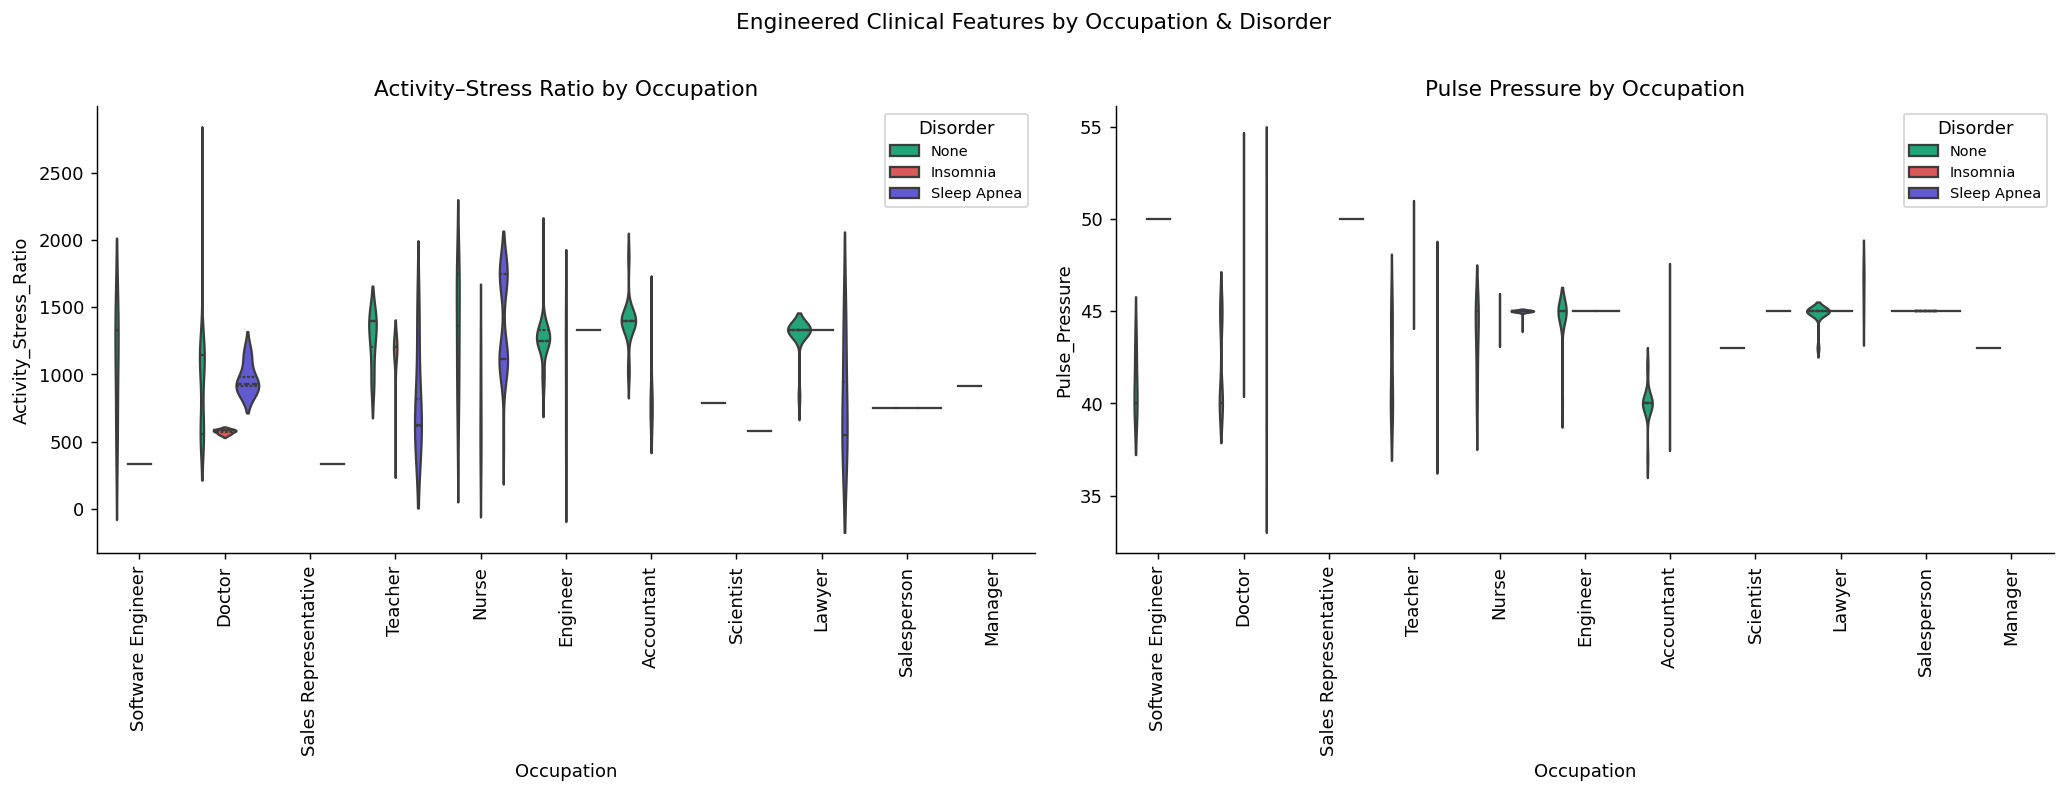

In [72]:
# Violin plot of Engineered feature profiles by occupation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='Occupation', y='Activity_Stress_Ratio',
               hue='Sleep Disorder', hue_order=['None','Insomnia','Sleep Apnea'],
               palette=CLASS_COLORS, split=False, ax=axes[0], inner='quartile')
axes[0].set_title('Activity–Stress Ratio by Occupation')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Disorder', fontsize=8)

sns.violinplot(data=df, x='Occupation', y='Pulse_Pressure',
               hue='Sleep Disorder', hue_order=['None','Insomnia','Sleep Apnea'],
               palette=CLASS_COLORS, split=False, ax=axes[1], inner='quartile')
axes[1].set_title('Pulse Pressure by Occupation')
axes[1].tick_params(axis='x', rotation= 90)
axes[1].legend(title='Disorder', fontsize=8)

plt.suptitle('Engineered Clinical Features by Occupation & Disorder', y=1.01)
plt.tight_layout()
plt.show()